In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/natsumekafka/vietnamese-ai-detection-v0/val.csv
/kaggle/input/datasets/natsumekafka/vietnamese-ai-detection-v0/train.csv
/kaggle/input/datasets/natsumekafka/vietnamese-ai-detection-v0/test.csv
/kaggle/input/datasets/natsumekafka/vietnamese-ai-detection-v0/dataset.csv


In [2]:
!pip install transformers datasets torch scikit-learn -q

In [3]:
import pandas as pd

BASE = "/kaggle/input/datasets/natsumekafka/vietnamese-ai-detection-v0"
train_df = pd.read_csv(f"{BASE}/train.csv")
val_df   = pd.read_csv(f"{BASE}/val.csv")
test_df  = pd.read_csv(f"{BASE}/test.csv")
print(train_df.shape, val_df.shape, test_df.shape)

(2993, 9) (374, 9) (375, 9)


In [4]:
# Kiểm tra label_int trong val
print(val_df["label_int"].value_counts())
print(val_df["label_int"].isna().sum())
print(val_df["label_int"].dtype)

# Kiểm tra text
print(val_df["text"].isna().sum())

label_int
1    187
0    187
Name: count, dtype: int64
0
int64
0


In [5]:
from transformers import AutoTokenizer
import torch
from torch.utils.data import Dataset

tokenizer = AutoTokenizer.from_pretrained("microsoft/mdeberta-v3-base")

class ViDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=512):
        encodings = tokenizer(
            list(df["text"]),
            truncation=True,
            padding=True,
            max_length=max_len
        )
        # Chỉ giữ input_ids và attention_mask, bỏ token_type_ids
        self.input_ids = encodings["input_ids"]
        self.attention_mask = encodings["attention_mask"]
        self.labels = list(df["label_int"])

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": torch.tensor(self.input_ids[idx]),
            "attention_mask": torch.tensor(self.attention_mask[idx]),
            "labels": torch.tensor(self.labels[idx])
        }

train_ds = ViDataset(train_df, tokenizer)
val_ds   = ViDataset(val_df,   tokenizer)
test_ds  = ViDataset(test_df,  tokenizer)
print("Keys:", train_ds[0].keys())
print("Datasets ready:", len(train_ds), len(val_ds), len(test_ds))

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

Keys: dict_keys(['input_ids', 'attention_mask', 'labels'])
Datasets ready: 2993 374 375


In [6]:
print(train_ds[0].keys())

dict_keys(['input_ids', 'attention_mask', 'labels'])


In [7]:
# Kiểm tra label trong dataset
print(train_ds[0]["labels"])
print(train_ds[1]["labels"])

# Kiểm tra thử 1 batch
from torch.utils.data import DataLoader
loader = DataLoader(train_ds, batch_size=2)
batch = next(iter(loader))
print("input_ids:", batch["input_ids"].shape)
print("attention_mask:", batch["attention_mask"].shape)
print("labels:", batch["labels"])
print("labels dtype:", batch["labels"].dtype)

tensor(0)
tensor(0)
input_ids: torch.Size([2, 512])
attention_mask: torch.Size([2, 512])
labels: tensor([0, 0])
labels dtype: torch.int64


In [8]:
from transformers import (AutoModelForSequenceClassification,
                           TrainingArguments, Trainer, EarlyStoppingCallback)
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from scipy.special import softmax
import numpy as np

model = AutoModelForSequenceClassification.from_pretrained(
    "microsoft/mdeberta-v3-base",
    num_labels=2,
    dtype=torch.float32
)
model = model.float()

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    probs = softmax(logits, axis=-1)[:, 1]   # ← xác suất class AI
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1":       f1_score(labels, preds, average="binary"),
        "auroc":    roc_auc_score(labels, probs),   # ← thêm mới
    }

args = TrainingArguments(
    output_dir="./mdeberta-ai-detection-v3",
    num_train_epochs=5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=8,
    warmup_steps=200,
    weight_decay=0.05,
    learning_rate=1e-5,
    label_smoothing_factor=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    fp16=False,
    bf16=False,
    logging_steps=50,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer.train()

pytorch_model.bin:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/mdeberta-v3-base
Key                                        | Status     | 
-------------------------------------------+------------+-
lm_predictions.lm_head.bias                | UNEXPECTED | 
mask_predictions.classifier.weight         | UNEXPECTED | 
mask_predictions.classifier.bias           | UNEXPECTED | 
mask_predictions.LayerNorm.bias            | UNEXPECTED | 
lm_predictions.lm_head.dense.bias          | UNEXPECTED | 
lm_predictions.lm_head.dense.weight        | UNEXPECTED | 
mask_predictions.dense.weight              | UNEXPECTED | 
deberta.embeddings.word_embeddings._weight | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight    | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias      | UNEXPECTED | 
mask_predictions.LayerNorm.weight          | UNEXPECTED | 
mask_predictions.dense.bias                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
pooler.dense.bias                  

Epoch,Training Loss,Validation Loss,Accuracy,F1,Auroc
1,0.521875,0.633858,0.943850,0.941828,0.987475
2,0.498859,0.555218,0.967914,0.968912,0.984215
3,0.490405,0.638444,0.951872,0.954082,0.988275
4,0.410665,0.522950,0.973262,0.973822,0.991535
5,0.429685,0.462790,0.986631,0.986667,0.991106


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye

TrainOutput(global_step=1875, training_loss=0.54649185740153, metrics={'train_runtime': 1654.393, 'train_samples_per_second': 9.046, 'train_steps_per_second': 1.133, 'total_flos': 3937527557191680.0, 'train_loss': 0.54649185740153, 'epoch': 5.0})

In [9]:
from sklearn.metrics import classification_report, confusion_matrix

pred_output = trainer.predict(test_ds)
preds  = np.argmax(pred_output.predictions, axis=-1)
probs  = softmax(pred_output.predictions, axis=-1)[:, 1]
labels = pred_output.label_ids

print("=== Test Metrics ===")
print(f"Accuracy : {accuracy_score(labels, preds):.4f}")
print(f"F1 (macro): {f1_score(labels, preds, average='macro'):.4f}")
print(f"AUROC    : {roc_auc_score(labels, probs):.4f}")

print("\n=== Classification Report ===")
print(classification_report(labels, preds, target_names=["human", "ai"]))

print("=== Confusion Matrix ===")
print(confusion_matrix(labels, preds))

=== Test Metrics ===
Accuracy : 0.9787
F1 (macro): 0.9787
AUROC    : 0.9958

=== Classification Report ===
              precision    recall  f1-score   support

       human       0.99      0.97      0.98       188
          ai       0.97      0.99      0.98       187

    accuracy                           0.98       375
   macro avg       0.98      0.98      0.98       375
weighted avg       0.98      0.98      0.98       375

=== Confusion Matrix ===
[[182   6]
 [  2 185]]


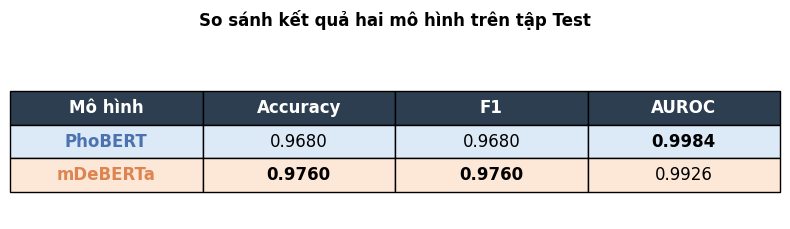

In [10]:
import matplotlib.pyplot as plt

C_PB   = "#4C72B0"
C_MD   = "#DD8452"

fig, ax = plt.subplots(figsize=(8, 2.2))
ax.axis("off")

rows = [
    ["PhoBERT",  "0.9680", "0.9680", "0.9984"],
    ["mDeBERTa", "0.9760", "0.9760", "0.9926"],
]
cols = ["Mô hình", "Accuracy", "F1", "AUROC"]

tbl = ax.table(cellText=rows, colLabels=cols, loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(12)
tbl.scale(1, 2.2)

for j in range(len(cols)):
    tbl[0, j].set_facecolor("#2c3e50")
    tbl[0, j].set_text_props(color="white", fontweight="bold")

tbl[1, 0].set_text_props(fontweight="bold", color=C_PB)
tbl[2, 0].set_text_props(fontweight="bold", color=C_MD)
for j in range(len(cols)):
    tbl[1, j].set_facecolor("#dce9f7")
    tbl[2, j].set_facecolor("#fde8d8")

# In đậm ô tốt hơn
for col_idx, best_row in [(1, 2), (2, 2), (3, 1)]:  # Acc/F1 → mDeBERTa, AUROC → PhoBERT
    tbl[best_row, col_idx].set_text_props(fontweight="bold")

fig.suptitle("So sánh kết quả hai mô hình trên tập Test",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("bang_so_sanh.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
trainer.save_model("/kaggle/working/mdeberta-finetuned")
tokenizer.save_pretrained("/kaggle/working/mdeberta-finetuned")
print("Saved!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved!


In [12]:
import os
for f in os.listdir("/kaggle/working/mdeberta-finetuned"):
    size = os.path.getsize(f"/kaggle/working/mdeberta-finetuned/{f}")
    print(f"{f}: {size/1024/1024:.1f} MB")

model.safetensors: 1063.6 MB
tokenizer_config.json: 0.0 MB
config.json: 0.0 MB
tokenizer.json: 15.3 MB
training_args.bin: 0.0 MB
